# Rich Graph GNN Experiments for CIC IIoT 2025

This notebook extends the earlier baseline notebook by building a **richer graph representation** and testing several GNN variants.

Research goal:

> Does a richer graph representation help GNN models get closer to, or outperform, the strongest tabular baseline (`k-NN`)?

This notebook does **not** replace the baseline notebook. It is an experimental extension focused on graph construction and GNN behavior.

## 1. What this notebook will do

The earlier graph design used mostly:

`device -> behavior_state`

This notebook expands the graph into a richer structure:

- `device -> behavior_state`
- `device -> ip`
- `device -> port`
- `device -> protocol`
- `device -> time_bucket`
- optionally: `time_bucket -> next_time_bucket`

Then we compare several GNN variants:

- **GCN**: graph convolutional network
- **GraphSAGE**: learns from self-node information plus neighbor information
- **GAT**: graph attention network
- **R-GCN-like**: relation-aware GCN using separate relation matrices

The temporal component is part of the graph design rather than a fifth independent GNN type: when `USE_TEMPORAL_EDGES = True`, all GNN encoders learn from the time-bucket nodes and sequential time edges.

We test training budgets of:

`20, 50, 80, 100, 150 epochs`

and plot whether each model keeps learning or starts overfitting/memorizing.

In [1]:
from pathlib import Path
from ast import literal_eval
from collections import Counter, defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 200)
plt.style.use('ggplot')

np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(4)

BASE_PATH = Path(r"/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch")
BENIGN_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Benign_data' / 'benign_samples_1sec.csv'
ATTACK_PATH = BASE_PATH / 'IoT_dataset' / 'CIC IIoT dataset 2025' / 'Attack_samples' / 'attack_samples_1sec.csv'

BENIGN_PATH, ATTACK_PATH

(PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Benign_data/benign_samples_1sec.csv'),
 PosixPath('/Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/IoT_dataset/CIC IIoT dataset 2025/Attack_samples/attack_samples_1sec.csv'))

## 2. Load the data

We keep the same binary classification task:

- `0 = benign`
- `1 = attack`

Each row is still a **1-second traffic window**. The difference is that we will now use more relational information from the row to build the graph.

In [2]:
benign_df = pd.read_csv(BENIGN_PATH)
attack_df = pd.read_csv(ATTACK_PATH)

benign_df['dataset_class'] = 'benign'
attack_df['dataset_class'] = 'attack'

combined_df = pd.concat([benign_df, attack_df], ignore_index=True)
combined_df['target'] = (combined_df['dataset_class'] == 'attack').astype(int)

print('Benign shape:', benign_df.shape)
print('Attack shape:', attack_df.shape)
print('Combined shape:', combined_df.shape)
print('\nTarget distribution:')
display(combined_df['target'].value_counts().rename(index={0: 'benign', 1: 'attack'}).to_frame('rows'))

Benign shape: (136800, 95)
Attack shape: (90391, 95)
Combined shape: (227191, 96)

Target distribution:


,rows
target,
benign,136800
attack,90391


## 3. Columns available for richer graph construction

A richer graph needs real entities, not only counts. This dataset contains real list-like columns for IPs, ports, and protocols. These are useful because they can become graph nodes.

Examples:

- `network_ips_all` can become `ip::<value>` nodes
- `network_ports_all` can become `port::<value>` nodes
- `network_protocols_all` can become `protocol::<value>` nodes

In [3]:
relationship_columns = [
    'device_name', 'timestamp_start', 'timestamp_end',
    'network_ips_all', 'network_ips_src', 'network_ips_dst',
    'network_ports_all', 'network_ports_src', 'network_ports_dst',
    'network_protocols_all', 'network_protocols_src', 'network_protocols_dst',
    'network_ips_all_count', 'network_ports_all_count', 'network_protocols_all_count'
]

available_relationship_columns = [c for c in relationship_columns if c in combined_df.columns]
print('Relationship columns available in this dataset:')
display(pd.DataFrame({'column': available_relationship_columns, 'dtype': [combined_df[c].dtype for c in available_relationship_columns]}))

print('Example values from the first non-empty rows:')
examples = []
for col in ['network_ips_all', 'network_ports_all', 'network_protocols_all']:
    non_empty = combined_df.loc[combined_df[col].astype(str) != '[]', col].head(5).tolist()
    examples.append({'column': col, 'example_values': non_empty[:3]})
display(pd.DataFrame(examples))

Relationship columns available in this dataset:


,column,dtype
0,device_name,str
1,timestamp_start,str
2,timestamp_end,str
3,network_ips_all,str
4,network_ips_src,str
5,network_ips_dst,str
6,network_ports_all,str
7,network_ports_src,str
8,network_ports_dst,str
9,network_protocols_all,str


Example values from the first non-empty rows:


,column,example_values
0,network_ips_all,"[['192.168.1.193', '192.168.230.7', '192.168.1..."
1,network_ports_all,"[['57688', '9200', '20002', '44935'], ['57688'..."
2,network_protocols_all,"[['tcp', 'data', 'json'], ['tcp', 'json'], ['t..."


## 4. Graph feature engineering settings

This is the most important part of the notebook.

In tabular feature engineering, we create new columns. In graph feature engineering, we create:

- node types,
- edge types,
- node vocabularies,
- relation matrices,
- and optional temporal links.

The settings below control how rich the graph becomes.

In [4]:
# Numeric behavior features to discretize into behavior-state nodes.
behavior_feature_candidates = [
    'network_packets_all_count',
    'network_packets_src_count',
    'network_packets_dst_count',
    'network_ports_dst_count',
    'network_ports_src_count',
    'network_ips_all_count',
    'network_protocols_all_count',
    'network_tcp-flags-ack_count',
    'network_tcp-flags-syn_count',
    'network_ip-length_max',
    'network_payload-length_avg',
    'network_time-delta_avg'
]
behavior_features = [c for c in behavior_feature_candidates if c in combined_df.columns]

# Limit high-cardinality entity vocabularies so the graph stays readable and runnable.
TOP_IPS = 120
TOP_PORTS = 120
TOP_PROTOCOLS = 40
MAX_VALUES_PER_ROW = 8

# Temporal setting: group timestamps by fixed bins and optionally connect consecutive bins.
TIME_BUCKET_SECONDS = 10
USE_TEMPORAL_EDGES = True

# Training settings. Set TRAIN_SAMPLE_CAP to an integer (e.g., 60000) for faster experimentation.
TRAIN_SAMPLE_CAP = None
EPOCH_CHECKPOINTS = [20, 50, 80, 100, 150]
HIDDEN_DIM = 64
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4

settings_df = pd.DataFrame({
    'setting': ['TOP_IPS', 'TOP_PORTS', 'TOP_PROTOCOLS', 'MAX_VALUES_PER_ROW', 'TIME_BUCKET_SECONDS', 'USE_TEMPORAL_EDGES', 'TRAIN_SAMPLE_CAP', 'EPOCH_CHECKPOINTS', 'HIDDEN_DIM'],
    'value': [TOP_IPS, TOP_PORTS, TOP_PROTOCOLS, MAX_VALUES_PER_ROW, TIME_BUCKET_SECONDS, USE_TEMPORAL_EDGES, TRAIN_SAMPLE_CAP, str(EPOCH_CHECKPOINTS), HIDDEN_DIM]
})
display(settings_df)

,setting,value
0,TOP_IPS,120
1,TOP_PORTS,120
2,TOP_PROTOCOLS,40
3,MAX_VALUES_PER_ROW,8
4,TIME_BUCKET_SECONDS,10
5,USE_TEMPORAL_EDGES,True
6,TRAIN_SAMPLE_CAP,None
7,EPOCH_CHECKPOINTS,"[20, 50, 80, 100, 150]"
8,HIDDEN_DIM,64


## 5. Helper functions for graph feature engineering

The list columns are stored as strings like:

`['tcp', 'json']`

so we parse them into Python lists. Then we create capped entity lists so the graph does not explode in size.

In [5]:
def parse_list_cell(value):
    """Parse CIC list-like strings safely into Python lists."""
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if text in ('', '[]', 'nan', 'None'):
        return []
    try:
        parsed = literal_eval(text)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
        return [str(parsed)]
    except Exception:
        return [text]


def top_values_from_column(series, top_k):
    counter = Counter()
    for value in series.dropna():
        counter.update(parse_list_cell(value))
    return set([value for value, _ in counter.most_common(top_k)])


def capped_values(value, allowed_values, prefix, max_values=MAX_VALUES_PER_ROW):
    values = parse_list_cell(value)
    clean = []
    for item in values:
        item = str(item).strip()
        if not item:
            continue
        if item in allowed_values:
            clean.append(f'{prefix}::{item}')
        else:
            clean.append(f'{prefix}::OTHER')
    # Keep unique values while preserving order.
    clean = list(dict.fromkeys(clean))[:max_values]
    return clean


def make_time_bucket(series, seconds=10):
    ts = pd.to_datetime(series, errors='coerce', utc=True)
    # floor to a stable bucket. Missing timestamps go to UNKNOWN.
    bucket = ts.dt.floor(f'{seconds}s').astype(str)
    return bucket.where(ts.notna(), 'UNKNOWN_TIME')

## 6. Train/test split and optional training sample

We use a stratified split so the benign/attack proportion is preserved in training, validation, and test partitions.

The graph itself is built from the **training partition only** to avoid leaking information from the test set into the graph vocabulary and edge structure.

In [6]:
all_indices = np.arange(len(combined_df))
y_all = combined_df['target'].values

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.20,
    random_state=42,
    stratify=y_all[train_idx]
)

if TRAIN_SAMPLE_CAP is not None and len(train_idx) > TRAIN_SAMPLE_CAP:
    train_sample_df = combined_df.iloc[train_idx][['target']].copy()
    sampled = []
    for target_value, frame in train_sample_df.groupby('target'):
        n = max(1, int(TRAIN_SAMPLE_CAP * len(frame) / len(train_sample_df)))
        sampled.append(frame.sample(n=min(n, len(frame)), random_state=42).index.to_numpy())
    train_idx = np.concatenate(sampled)

train_df = combined_df.iloc[train_idx].copy()
val_df = combined_df.iloc[val_idx].copy()
test_df = combined_df.iloc[test_idx].copy()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'benign_rows': [(train_df['target']==0).sum(), (val_df['target']==0).sum(), (test_df['target']==0).sum()],
    'attack_rows': [(train_df['target']==1).sum(), (val_df['target']==1).sum(), (test_df['target']==1).sum()],
})
split_summary['attack_rate'] = split_summary['attack_rows'] / split_summary['rows']
display(split_summary)

,split,rows,benign_rows,attack_rows,attack_rate
0,train,145401,87552,57849,0.397858
1,validation,36351,21888,14463,0.397871
2,test,45439,27360,18079,0.397874


## 7. Build graph vocabularies

We now build the entity vocabularies from training data only:

- top IPs,
- top ports,
- top protocols,
- time buckets,
- and behavior states.

Any rare IP/port/protocol is mapped into an `OTHER` node so the model can still represent rare entities without creating thousands of nodes.

In [7]:
for c in behavior_features:
    train_df[c] = pd.to_numeric(train_df[c], errors='coerce').fillna(0)
    val_df[c] = pd.to_numeric(val_df[c], errors='coerce').fillna(0)
    test_df[c] = pd.to_numeric(test_df[c], errors='coerce').fillna(0)

allowed_ips = top_values_from_column(train_df['network_ips_all'], TOP_IPS)
allowed_ports = top_values_from_column(train_df['network_ports_all'], TOP_PORTS)
allowed_protocols = top_values_from_column(train_df['network_protocols_all'], TOP_PROTOCOLS)

bin_labels = ['very-low', 'low', 'high', 'very-high']
feature_bin_edges = {}
for feature in behavior_features:
    edges = np.unique(train_df[feature].quantile([0, 0.25, 0.50, 0.75, 1.0]).to_numpy())
    if len(edges) < 3:
        edges = np.unique(train_df[feature].quantile([0, 0.50, 1.0]).to_numpy())
    feature_bin_edges[feature] = edges

feature_engineering_summary = pd.DataFrame({
    'entity_or_feature_group': ['IPs', 'Ports', 'Protocols', 'Behavior numeric features'],
    'how_represented_in_graph': ['ip::<value>', 'port::<value>', 'protocol::<value>', 'feature::state'],
    'vocabulary_size_or_count': [len(allowed_ips), len(allowed_ports), len(allowed_protocols), len(behavior_features)]
})
print('Table 1. Rich graph feature-engineering summary')
display(feature_engineering_summary)

bin_df = pd.DataFrame([
    {
        'feature': feature,
        'cut_points_from_training_data': ', '.join([f'{x:.3f}' for x in feature_bin_edges[feature]])
    }
    for feature in behavior_features
])
print('Table 2. Numeric behavior features and discretization cut points')
display(bin_df)

Table 1. Rich graph feature-engineering summary


,entity_or_feature_group,how_represented_in_graph,vocabulary_size_or_count
0,IPs,ip::<value>,120
1,Ports,port::<value>,120
2,Protocols,protocol::<value>,40
3,Behavior numeric features,feature::state,12


Table 2. Numeric behavior features and discretization cut points


,feature,cut_points_from_training_data
0,network_packets_all_count,"0.000, 2.000, 50.000, 149004.000"
1,network_packets_src_count,"0.000, 1.000, 8.000, 67113.000"
2,network_packets_dst_count,"0.000, 1.000, 25.000, 149004.000"
3,network_ports_dst_count,"0.000, 1.000, 6.000, 48952.000"
4,network_ports_src_count,"0.000, 2.000, 12.000, 65916.000"
5,network_ips_all_count,"0.000, 2.000, 238.000"
6,network_protocols_all_count,"0.000, 1.000, 2.000, 19.000"
7,network_tcp-flags-ack_count,"0.000, 7.000, 115947.000"
8,network_tcp-flags-syn_count,"0.000, 122231.000"
9,network_ip-length_max,"0.000, 44.000, 96.000, 11636.000"


## 8. Convert each row into graph-ready features

This table is important: it shows how the original dataframe becomes graph-ready.

Each row keeps its `device_name`, `target`, and timestamp information, but now also has lists of graph nodes:

- `state_nodes`
- `ip_nodes`
- `port_nodes`
- `protocol_nodes`
- `time_node`

This is the direct bridge from tabular data to graph data.

In [8]:
def assign_state(value, edges):
    if pd.isna(value):
        return 'missing'
    if len(edges) == 2:
        return 'low' if value <= edges[0] else 'high'
    state_index = np.searchsorted(edges[1:-1], value, side='right')
    labels = bin_labels[:len(edges) - 1]
    return labels[min(state_index, len(labels) - 1)]


def add_graph_ready_columns(frame):
    frame = frame.copy()
    frame['time_bucket'] = make_time_bucket(frame['timestamp_start'], TIME_BUCKET_SECONDS)
    frame['device_node'] = 'device::' + frame['device_name'].astype(str)
    frame['time_node'] = 'time::' + frame['time_bucket'].astype(str)

    frame['state_nodes'] = frame.apply(
        lambda row: [f'state::{feature}::{assign_state(row[feature], feature_bin_edges[feature])}' for feature in behavior_features],
        axis=1
    )
    frame['ip_nodes'] = frame['network_ips_all'].apply(lambda x: capped_values(x, allowed_ips, 'ip'))
    frame['port_nodes'] = frame['network_ports_all'].apply(lambda x: capped_values(x, allowed_ports, 'port'))
    frame['protocol_nodes'] = frame['network_protocols_all'].apply(lambda x: capped_values(x, allowed_protocols, 'protocol'))

    frame['context_nodes'] = frame.apply(
        lambda row: row['state_nodes'] + row['ip_nodes'] + row['port_nodes'] + row['protocol_nodes'] + [row['time_node']],
        axis=1
    )
    frame['context_node_count'] = frame['context_nodes'].apply(len)
    return frame

train_graph_df = add_graph_ready_columns(train_df)
val_graph_df = add_graph_ready_columns(val_df)
test_graph_df = add_graph_ready_columns(test_df)

preview_cols = ['device_name', 'target', 'timestamp_start', 'time_bucket', 'state_nodes', 'ip_nodes', 'port_nodes', 'protocol_nodes', 'context_node_count']
print('Table 3. Example graph-ready dataframe')
display(train_graph_df[preview_cols].head(10))

Table 3. Example graph-ready dataframe


,device_name,target,timestamp_start,time_bucket,state_nodes,ip_nodes,port_nodes,protocol_nodes,context_node_count
5194,mqtt-broker,0,2025-09-09T14:36:14.400000Z,2025-09-09 14:36:10+00:00,"[state::network_packets_all_count::low, state:...","[ip::192.168.1.193, ip::192.168.1.10, ip::192....","[port::1883, port::OTHER, port::9200]","[protocol::tcp, protocol::mqtt, protocol::json...",28
131069,plug-cameras-dekco-blurams,0,2025-09-09T14:34:09.400000Z,2025-09-09 14:34:00+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[],13
10694,edge1,0,2025-09-09T15:07:54.400000Z,2025-09-09 15:07:50+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[],13
58497,motion-sensor,0,2025-09-09T14:24:37.400000Z,2025-09-09 14:24:30+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[],13
45764,ultrasonic-sensor,0,2025-09-09T14:52:24.400000Z,2025-09-09 14:52:20+00:00,"[state::network_packets_all_count::low, state:...","[ip::192.168.1.193, ip::192.168.1.17]","[port::1883, port::OTHER]","[protocol::tcp, protocol::mqtt]",19
54760,proximity-collision-sensor,0,2025-09-09T14:22:20.400000Z,2025-09-09 14:22:20+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[],13
161062,soil-sensor,1,2025-01-16T19:54:42.083000Z,2025-01-16 19:54:40+00:00,"[state::network_packets_all_count::high, state...","[ip::192.168.1.12, ip::192.168.1.100]","[port::1883, port::OTHER, port::1, port::3, po...",[protocol::tcp],24
78892,dekco-camera,0,2025-09-09T15:04:32.400000Z,2025-09-09 15:04:30+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[],13
89365,wisenet-camera,0,2025-09-09T14:59:05.400000Z,2025-09-09 14:59:00+00:00,"[state::network_packets_all_count::very-low, s...",[],[],[protocol::lldp],14
206341,edge1,1,2025-02-04T21:22:57.865000Z,2025-02-04 21:22:50+00:00,"[state::network_packets_all_count::low, state:...","[ip::192.168.1.195, ip::192.168.1.100, ip::192...","[port::OTHER, port::53]","[protocol::tcp, protocol::data, protocol::data...",23


### Interpretation of the graph-ready dataframe

Each row still represents one 1-second window, but it is no longer only a flat vector of numbers.

Example interpretation:

- `device_name` becomes a **device node**.
- Numeric traffic values become **behavior-state nodes** such as `packets_all::high`.
- Real ports become **port nodes** such as `port::1883`.
- Real protocols become **protocol nodes** such as `protocol::tcp`.
- Time becomes a **time node**, which allows temporal context.

This is graph feature engineering: instead of creating only new columns, we create a network of entities and relationships.

## 9. Build the rich graph

We now construct the graph from the training split only.

Node types:

- device
- state
- ip
- port
- protocol
- time

Edge types:

- device--state
- device--ip
- device--port
- device--protocol
- device--time
- time--next_time (optional temporal edge)

The GNN will learn node embeddings from this graph, then classify each 1-second window using:

`device embedding + average context-node embedding`

In [9]:
RELATIONS = ['device_state', 'device_ip', 'device_port', 'device_protocol', 'device_time', 'time_next']

edge_counter = Counter()
edge_type_counter = Counter()
node_type = {}


def register_node(node):
    if node.startswith('device::'):
        node_type[node] = 'device'
    elif node.startswith('state::'):
        node_type[node] = 'state'
    elif node.startswith('ip::'):
        node_type[node] = 'ip'
    elif node.startswith('port::'):
        node_type[node] = 'port'
    elif node.startswith('protocol::'):
        node_type[node] = 'protocol'
    elif node.startswith('time::'):
        node_type[node] = 'time'
    else:
        node_type[node] = 'unknown'


def add_edge(u, v, relation):
    register_node(u)
    register_node(v)
    a, b = sorted([u, v])
    edge_counter[(a, b, relation)] += 1
    edge_type_counter[relation] += 1

for _, row in train_graph_df.iterrows():
    device = row['device_node']
    for node in row['state_nodes']:
        add_edge(device, node, 'device_state')
    for node in row['ip_nodes']:
        add_edge(device, node, 'device_ip')
    for node in row['port_nodes']:
        add_edge(device, node, 'device_port')
    for node in row['protocol_nodes']:
        add_edge(device, node, 'device_protocol')
    add_edge(device, row['time_node'], 'device_time')

if USE_TEMPORAL_EDGES:
    ordered_time_nodes = sorted(train_graph_df['time_node'].dropna().unique())
    for current_time, next_time in zip(ordered_time_nodes[:-1], ordered_time_nodes[1:]):
        add_edge(current_time, next_time, 'time_next')

nodes = sorted(node_type.keys())
node_to_idx = {node: idx for idx, node in enumerate(nodes)}
n_nodes = len(nodes)

node_type_summary = pd.Series(node_type).value_counts().rename_axis('node_type').reset_index(name='count')
edge_type_summary = pd.DataFrame({'edge_type': list(edge_type_counter.keys()), 'edge_count': list(edge_type_counter.values())}).sort_values('edge_count', ascending=False)

print('Table 4. Node type summary')
display(node_type_summary)
print('Table 5. Edge type summary')
display(edge_type_summary)
print('Total nodes:', n_nodes)
print('Total unique typed edges:', len(edge_counter))

Table 4. Node type summary


,node_type,count
0,time,7353
1,port,121
2,ip,82
3,protocol,41
4,device,38
5,state,33


Table 5. Edge type summary


,edge_type,edge_count
0,device_state,1744812
1,device_ip,302348
2,device_port,245276
3,device_protocol,196861
4,device_time,145401
5,time_next,7352


Total nodes: 7668
Total unique typed edges: 38093


## 10. Visualize a sample of the rich graph

The full graph is too large to draw clearly, so we draw a small subgraph for one representative attack device.

How to interpret:

- The center is a device node.
- Neighbor nodes show behavior states, IPs, ports, protocols, and time buckets connected to that device.
- More node types means the graph gives the GNN more relational context than the earlier simple `device -> state` graph.

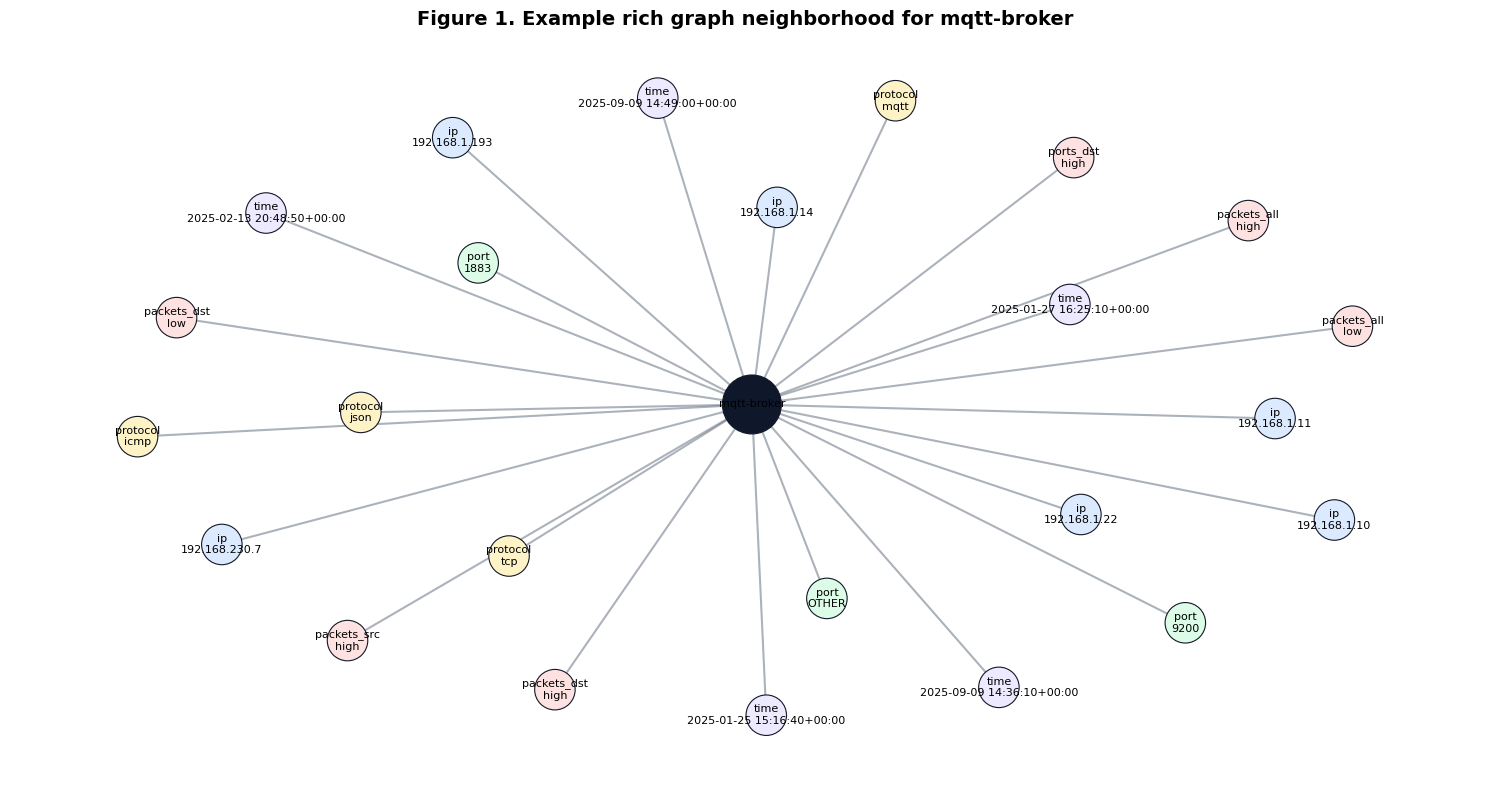

In [10]:
# Choose the most frequent attack device in the training graph.
example_device = train_graph_df.loc[train_graph_df['target'] == 1, 'device_node'].value_counts().index[0]
example_rows = train_graph_df[train_graph_df['device_node'] == example_device].head(80)

sample_neighbors = []
for _, row in example_rows.iterrows():
    sample_neighbors.extend(row['state_nodes'][:4])
    sample_neighbors.extend(row['ip_nodes'][:3])
    sample_neighbors.extend(row['port_nodes'][:3])
    sample_neighbors.extend(row['protocol_nodes'][:3])
    sample_neighbors.append(row['time_node'])
sample_neighbors = list(dict.fromkeys(sample_neighbors))[:24]

G_vis = nx.Graph()
G_vis.add_node(example_device, kind='device')
for node in sample_neighbors:
    G_vis.add_node(node, kind=node_type.get(node, 'unknown'))
    G_vis.add_edge(example_device, node)

color_map = {
    'device': '#0f172a',
    'state': '#fee2e2',
    'ip': '#dbeafe',
    'port': '#dcfce7',
    'protocol': '#fef3c7',
    'time': '#ede9fe',
    'unknown': '#f3f4f6'
}
node_colors = [color_map.get(G_vis.nodes[n].get('kind'), '#f3f4f6') for n in G_vis.nodes]
node_sizes = [1800 if n == example_device else 850 for n in G_vis.nodes]

pos = nx.spring_layout(G_vis, seed=42, k=0.8)
fig, ax = plt.subplots(figsize=(15, 8))
nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.45, width=1.5, edge_color='#475569')
nx.draw_networkx_nodes(G_vis, pos, ax=ax, node_color=node_colors, node_size=node_sizes, edgecolors='#111827', linewidths=0.8)

labels = {}
for node in G_vis.nodes:
    if node == example_device:
        labels[node] = node.replace('device::', '')
    else:
        labels[node] = node.replace('state::network_', '').replace('_count', '').replace('::', '\n')[:38]
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8, ax=ax)
ax.set_title(f'Figure 1. Example rich graph neighborhood for {example_device.replace("device::", "")}', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 11. Build adjacency matrices and sample encodings

We build:

- one normalized adjacency matrix for GCN/GraphSAGE/GAT,
- one relation-specific adjacency matrix per edge type for the R-GCN-like model,
- and encoded samples for train/validation/test.

In [11]:
A = np.zeros((n_nodes, n_nodes), dtype=np.float32)
relation_adj = {rel: np.zeros((n_nodes, n_nodes), dtype=np.float32) for rel in RELATIONS}

for (u, v, rel), weight in edge_counter.items():
    if u not in node_to_idx or v not in node_to_idx:
        continue
    i, j = node_to_idx[u], node_to_idx[v]
    A[i, j] = 1.0
    A[j, i] = 1.0
    relation_adj[rel][i, j] = 1.0
    relation_adj[rel][j, i] = 1.0

np.fill_diagonal(A, 1.0)
for rel in RELATIONS:
    np.fill_diagonal(relation_adj[rel], 1.0)

# Normalized adjacency for GCN.
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-8)))
A_norm = torch.tensor(D_inv_sqrt @ A @ D_inv_sqrt, dtype=torch.float32)

# Mean adjacency for GraphSAGE.
A_mean = torch.tensor(A / np.maximum(deg[:, None], 1e-8), dtype=torch.float32)
A_mask = torch.tensor(A > 0, dtype=torch.bool)

relation_norm = []
for rel in RELATIONS:
    R = relation_adj[rel]
    rdeg = R.sum(axis=1)
    relation_norm.append(torch.tensor(R / np.maximum(rdeg[:, None], 1e-8), dtype=torch.float32))

print('Adjacency shape:', A_norm.shape)
print('Relation matrices:', len(relation_norm))

Adjacency shape: torch.Size([7668, 7668])
Relation matrices: 6


In [12]:
def encode_graph_samples(frame):
    device_idx = []
    context_idx = []
    labels = []
    for _, row in frame.iterrows():
        dev = row['device_node']
        context = [node for node in row['context_nodes'] if node in node_to_idx]
        if not context:
            context = [dev]
        device_idx.append(node_to_idx.get(dev, 0))
        context_idx.append([node_to_idx[node] for node in context])
        labels.append(int(row['target']))

    max_len = max(len(x) for x in context_idx)
    padded = np.zeros((len(context_idx), max_len), dtype=np.int64)
    mask = np.zeros((len(context_idx), max_len), dtype=np.float32)
    for i, values in enumerate(context_idx):
        padded[i, :len(values)] = values
        mask[i, :len(values)] = 1.0

    return (
        torch.tensor(device_idx, dtype=torch.long),
        torch.tensor(padded, dtype=torch.long),
        torch.tensor(mask, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.float32)
    )

train_dev, train_context, train_mask, train_y = encode_graph_samples(train_graph_df)
val_dev, val_context, val_mask, val_y = encode_graph_samples(val_graph_df)
test_dev, test_context, test_mask, test_y = encode_graph_samples(test_graph_df)

print('Train encoded:', train_dev.shape, train_context.shape, train_y.shape)
print('Validation encoded:', val_dev.shape, val_context.shape, val_y.shape)
print('Test encoded:', test_dev.shape, test_context.shape, test_y.shape)

Train encoded: torch.Size([145401]) torch.Size([145401, 37]) torch.Size([145401])
Validation encoded: torch.Size([36351]) torch.Size([36351, 37]) torch.Size([36351])
Test encoded: torch.Size([45439]) torch.Size([45439, 36]) torch.Size([45439])


## 12. Define GNN variants

A **Graph Neural Network (GNN)** is a neural network designed for data that has relationships. In a normal tabular model, each row is treated mostly as an independent feature vector. In a GNN, the model also uses the graph structure: which nodes are connected, what type of nodes they are, and what information can flow from one node to another.

In this notebook, a 1-second traffic window is classified using this idea:

`device embedding + mean(context embeddings) -> attack probability`

That means the model learns an embedding for the device node, learns embeddings for the connected context nodes, and then predicts whether the window is benign or attack. The context can include behavior states, IP nodes, port nodes, protocol nodes, and time nodes. What changes across the models below is **how the GNN encoder updates the node embeddings**.

### GCN: Graph Convolutional Network

A **GCN** is the most direct graph version of a convolutional neural network. The basic idea is: each node updates its representation by averaging information from its neighbors. If a device node is connected to states such as `network_packets_all_count::high`, `network_ports_dst_count::high`, and `protocol::tcp`, the GCN mixes those neighboring signals into the device embedding.

A simple way to think about GCN is:

`new node representation = transformed average of the node + its neighbors`

For this IIoT project, GCN asks: **does the local neighborhood around a device look more like normal behavior or attack behavior?** It is useful as a first GNN baseline because it is simple and stable. However, it treats most neighbors in a similar averaged way, so it may miss cases where one specific neighbor, such as a suspicious port or protocol, is more important than the others.

### GraphSAGE: Sample and Aggregate

**GraphSAGE** also learns from neighbors, but its main idea is to learn an **aggregation function**. Instead of learning only one embedding for a fixed graph, GraphSAGE learns how to generate embeddings from node features and neighbor features. This makes it especially useful when graphs are large or when new nodes may appear later.

A simple way to think about GraphSAGE is:

`new node representation = combine(self information, aggregated neighbor information)`

For this IIoT project, GraphSAGE is attractive because future datasets may contain new devices, new ports, or new IP patterns. It is also a good fit when we want the model to learn from a node's local context without requiring the entire graph to be identical every time. In practice, GraphSAGE often works well when the graph is rich but still noisy.

### GAT: Graph Attention Network

**GAT** adds an attention mechanism. Instead of averaging all neighbors equally, the model learns which neighbors deserve more weight. This is important because in cybersecurity not every relation is equally informative. For example, a common protocol node may be less important than an unusual destination port or a rare behavior-state combination.

A simple way to think about GAT is:

`new node representation = weighted combination of neighbors, where the weights are learned`

For this IIoT project, GAT asks: **which connected nodes should the model pay more attention to when deciding if this window is an attack?** This is conceptually useful for interpretability, but it can be harder to train and may need more careful tuning than GCN or GraphSAGE.

### R-GCN-like: Relation-aware Graph Convolution

**R-GCN** was designed for multi-relational graphs, especially knowledge graphs. A normal GCN mostly sees that two nodes are connected. An R-GCN also considers **what kind of relationship** connects them. In our graph, this matters because `device -> state`, `device -> IP`, `device -> port`, `device -> protocol`, and `device -> time` do not mean the same thing.

A simple way to think about R-GCN-like is:

`new node representation = combine messages from neighbors, but use different transformations for different edge types`

For this IIoT project, R-GCN-like is the closest model to the **knowledge graph** idea because it preserves semantic differences between relationship types. If the model performs well, it suggests that the type of relation matters, not just the existence of a connection.

### Why compare these GNNs?

We compare these architectures because each one tests a different graph-learning assumption:

- **GCN** tests whether simple neighborhood smoothing is enough.
- **GraphSAGE** tests whether learned neighbor aggregation improves the representation.
- **GAT** tests whether attention over neighbors helps identify the most important graph signals.
- **R-GCN-like** tests whether relation types improve detection in a knowledge-graph-style representation.

Important note: the time-bucket nodes and temporal edges are already included in the rich graph when `USE_TEMPORAL_EDGES = True`. Therefore, the comparison below keeps the model list focused on architecture differences instead of duplicating GraphSAGE under another name.

### Sources used for these definitions

- Kipf and Welling introduced GCN as a scalable neural architecture for graph-structured data in **ICLR 2017**: [Semi-Supervised Classification with Graph Convolutional Networks](https://arxiv.org/pdf/1609.02907).
- Hamilton, Ying, and Leskovec introduced GraphSAGE in **NeurIPS 2017** as an inductive framework that samples and aggregates neighborhood information: [Inductive Representation Learning on Large Graphs](https://papers.neurips.cc/paper/6703-inductive-representation-learning-on-large-graphs).
- Veličković et al. introduced GAT in **ICLR 2018**, using attention over graph neighborhoods: [Graph Attention Networks](https://iclr.cc/virtual/2018/poster/299).
- Schlichtkrull et al. introduced R-GCN for multi-relational data and knowledge graphs in **ESWC 2018**: [Modeling Relational Data with Graph Convolutional Networks](https://link.springer.com/chapter/10.1007/978-3-319-93417-4_38).

In [13]:
class GCNEncoder(nn.Module):
    def __init__(self, n_nodes, hidden_dim=64):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(n_nodes, hidden_dim) * 0.05)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
    def forward(self):
        h = A_norm @ self.emb
        h = F.relu(self.lin1(h))
        z = A_norm @ h
        z = self.lin2(z)
        return z


class GraphSAGEEncoder(nn.Module):
    def __init__(self, n_nodes, hidden_dim=64):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(n_nodes, hidden_dim) * 0.05)
        self.self1 = nn.Linear(hidden_dim, hidden_dim)
        self.neigh1 = nn.Linear(hidden_dim, hidden_dim)
        self.self2 = nn.Linear(hidden_dim, hidden_dim)
        self.neigh2 = nn.Linear(hidden_dim, hidden_dim)
    def forward(self):
        h0 = self.emb
        n0 = A_mean @ h0
        h = F.relu(self.self1(h0) + self.neigh1(n0))
        n1 = A_mean @ h
        z = self.self2(h) + self.neigh2(n1)
        return z


class GATLayer(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.a_src = nn.Parameter(torch.randn(hidden_dim) * 0.05)
        self.a_dst = nn.Parameter(torch.randn(hidden_dim) * 0.05)
    def forward(self, h):
        Wh = self.W(h)
        e = Wh @ self.a_src + (Wh @ self.a_dst).unsqueeze(0).T
        e = F.leaky_relu(e, negative_slope=0.2)
        e = e.masked_fill(~A_mask, -1e9)
        alpha = torch.softmax(e, dim=1)
        return alpha @ Wh


class GATEncoder(nn.Module):
    def __init__(self, n_nodes, hidden_dim=64):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(n_nodes, hidden_dim) * 0.05)
        self.gat1 = GATLayer(hidden_dim)
        self.gat2 = GATLayer(hidden_dim)
    def forward(self):
        h = F.elu(self.gat1(self.emb))
        z = self.gat2(h)
        return z


class RGCNLikeEncoder(nn.Module):
    def __init__(self, n_nodes, hidden_dim=64, n_relations=None):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(n_nodes, hidden_dim) * 0.05)
        self.rel1 = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(n_relations)])
        self.rel2 = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(n_relations)])
        self.self1 = nn.Linear(hidden_dim, hidden_dim)
        self.self2 = nn.Linear(hidden_dim, hidden_dim)
    def forward(self):
        h0 = self.emb
        h = self.self1(h0)
        for R, layer in zip(relation_norm, self.rel1):
            h = h + layer(R @ h0)
        h = F.relu(h)
        z = self.self2(h)
        for R, layer in zip(relation_norm, self.rel2):
            z = z + layer(R @ h)
        return z


class WindowClassifier(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, z, dev_idx, context_idx, context_mask):
        dev_z = z[dev_idx]
        context_z = z[context_idx]
        masked_context = context_z * context_mask.unsqueeze(-1)
        context_mean = masked_context.sum(dim=1) / context_mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return self.net(torch.cat([dev_z, context_mean], dim=1)).squeeze(1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 13. Training and evaluation functions

We train each model up to the maximum epoch (`150`) and evaluate at checkpoints:

`20, 50, 80, 100, 150`

This is more efficient than training from scratch five times.

### How to interpret learning vs memorizing

A GNN is still learning when validation F1 improves as epochs increase.

A model may be overfitting or memorizing when:

- training loss keeps decreasing,
- training F1 keeps increasing,
- but validation F1 stops improving or starts decreasing.

If validation F1 flattens, the model may have reached its useful learning limit.

In [14]:
def metric_dict(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    preds = (np.asarray(probs) >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall': recall_score(y_true, preds, zero_division=0),
        'f1': f1_score(y_true, preds, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probs),
        'threshold': threshold,
        'tn': confusion_matrix(y_true, preds)[0, 0],
        'fp': confusion_matrix(y_true, preds)[0, 1],
        'fn': confusion_matrix(y_true, preds)[1, 0],
        'tp': confusion_matrix(y_true, preds)[1, 1]
    }


def tune_threshold_from_probs(y_true, probs):
    best_threshold, best_f1 = 0.5, -1
    for threshold in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(np.asarray(y_true).astype(int), (np.asarray(probs) >= threshold).astype(int), zero_division=0)
        if f1 > best_f1:
            best_threshold = float(threshold)
            best_f1 = f1
    return best_threshold


def predict_probs(encoder, classifier, dev, context, mask):
    encoder.eval()
    classifier.eval()
    with torch.no_grad():
        z = encoder()
        logits = classifier(z, dev, context, mask)
        return torch.sigmoid(logits).cpu().numpy()


def train_gnn_variant(model_name, encoder_factory, max_epochs=max(EPOCH_CHECKPOINTS)):
    torch.manual_seed(42)
    encoder = encoder_factory()
    classifier = WindowClassifier(hidden_dim=HIDDEN_DIM)
    params = list(encoder.parameters()) + list(classifier.parameters())
    optimizer = torch.optim.Adam(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    neg = (train_y == 0).sum().item()
    pos = (train_y == 1).sum().item()
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    history = []
    checkpoint_rows = []
    best_val_f1 = -1
    best_state = None
    best_threshold = 0.5

    for epoch in range(1, max_epochs + 1):
        encoder.train()
        classifier.train()
        z = encoder()
        logits = classifier(z, train_dev, train_context, train_mask)
        loss = loss_fn(logits, train_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch in EPOCH_CHECKPOINTS or epoch == 1:
            train_probs = predict_probs(encoder, classifier, train_dev, train_context, train_mask)
            val_probs = predict_probs(encoder, classifier, val_dev, val_context, val_mask)
            threshold = tune_threshold_from_probs(val_y.numpy(), val_probs)
            train_metrics = metric_dict(train_y.numpy(), train_probs, threshold)
            val_metrics = metric_dict(val_y.numpy(), val_probs, threshold)

            row = {
                'model': model_name,
                'epoch': epoch,
                'train_loss': float(loss.detach().cpu().numpy()),
                'threshold': threshold,
                'train_f1': train_metrics['f1'],
                'train_recall': train_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_recall': val_metrics['recall'],
                'val_precision': val_metrics['precision'],
                'val_roc_auc': val_metrics['roc_auc']
            }
            history.append(row)

            if val_metrics['f1'] > best_val_f1:
                best_val_f1 = val_metrics['f1']
                best_threshold = threshold
                best_state = {
                    'encoder': {k: v.detach().clone() for k, v in encoder.state_dict().items()},
                    'classifier': {k: v.detach().clone() for k, v in classifier.state_dict().items()},
                    'epoch': epoch
                }

    encoder.load_state_dict(best_state['encoder'])
    classifier.load_state_dict(best_state['classifier'])
    test_probs = predict_probs(encoder, classifier, test_dev, test_context, test_mask)
    test_metrics = metric_dict(test_y.numpy(), test_probs, best_threshold)
    test_metrics.update({
        'model': model_name,
        'best_epoch': best_state['epoch'],
        'parameters': count_parameters(encoder) + count_parameters(classifier),
        'hidden_dim': HIDDEN_DIM,
        'max_epochs': max_epochs,
        'nodes': n_nodes,
        'unique_edges': len(edge_counter)
    })

    return pd.DataFrame(history), test_metrics

## 14. Run the GNN comparison

This cell can take time because it trains multiple GNN variants up to 150 epochs.

For a fast first run, set `TRAIN_SAMPLE_CAP = 60000` near the top of the notebook and rerun from the split section.

For final paper-quality results, use the full training set.

In [15]:
gnn_variants = {
    'GCN-rich': lambda: GCNEncoder(n_nodes=n_nodes, hidden_dim=HIDDEN_DIM),
    'GraphSAGE-rich': lambda: GraphSAGEEncoder(n_nodes=n_nodes, hidden_dim=HIDDEN_DIM),
    'GAT-rich': lambda: GATEncoder(n_nodes=n_nodes, hidden_dim=HIDDEN_DIM),
    'R-GCN-like-rich': lambda: RGCNLikeEncoder(n_nodes=n_nodes, hidden_dim=HIDDEN_DIM, n_relations=len(RELATIONS)),
}

all_history = []
all_test_metrics = []

for model_name, factory in gnn_variants.items():
    print(f'Training {model_name}...')
    history_df, test_metrics = train_gnn_variant(model_name, factory)
    all_history.append(history_df)
    all_test_metrics.append(test_metrics)

history_df = pd.concat(all_history, ignore_index=True)
gnn_results_df = pd.DataFrame(all_test_metrics)

print('Table 6. Rich-graph GNN test results')
display(gnn_results_df[['model', 'best_epoch', 'parameters', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'threshold', 'tn', 'fp', 'fn', 'tp']].sort_values('f1', ascending=False).round(4))

Training GCN-rich...
Training GraphSAGE-rich...
Training GAT-rich...
Training R-GCN-like-rich...
Table 6. Rich-graph GNN test results


,model,best_epoch,parameters,accuracy,precision,recall,f1,roc_auc,threshold,tn,fp,fn,tp
3,R-GCN-like-rich,150,556545,1.0000,0.9999,1.0000,1.0000,1.0000,0.550,27359,1,0,18079
1,GraphSAGE-rich,100,515713,0.9982,0.9989,0.9966,0.9978,0.9998,0.255,27340,20,61,18018
2,GAT-rich,150,507521,0.9935,0.9909,0.9926,0.9918,0.9968,0.585,27196,164,133,17946
0,GCN-rich,150,507393,0.9298,0.9095,0.9147,0.9121,0.9707,0.050,25714,1646,1542,16537


## 15. Learning curves: when does the model stop learning?

The next plots compare training and validation behavior over epochs.

How to read them:

- If `train_f1` keeps rising and `val_f1` also rises, the model is still learning useful patterns.
- If `train_f1` rises but `val_f1` flattens or drops, the model may be memorizing training data.
- If both are flat, the model may have reached its learning limit with this graph representation.

Important: a curve flattening does not automatically mean overfitting. Overfitting is more likely when the training curve improves while the validation curve gets worse.

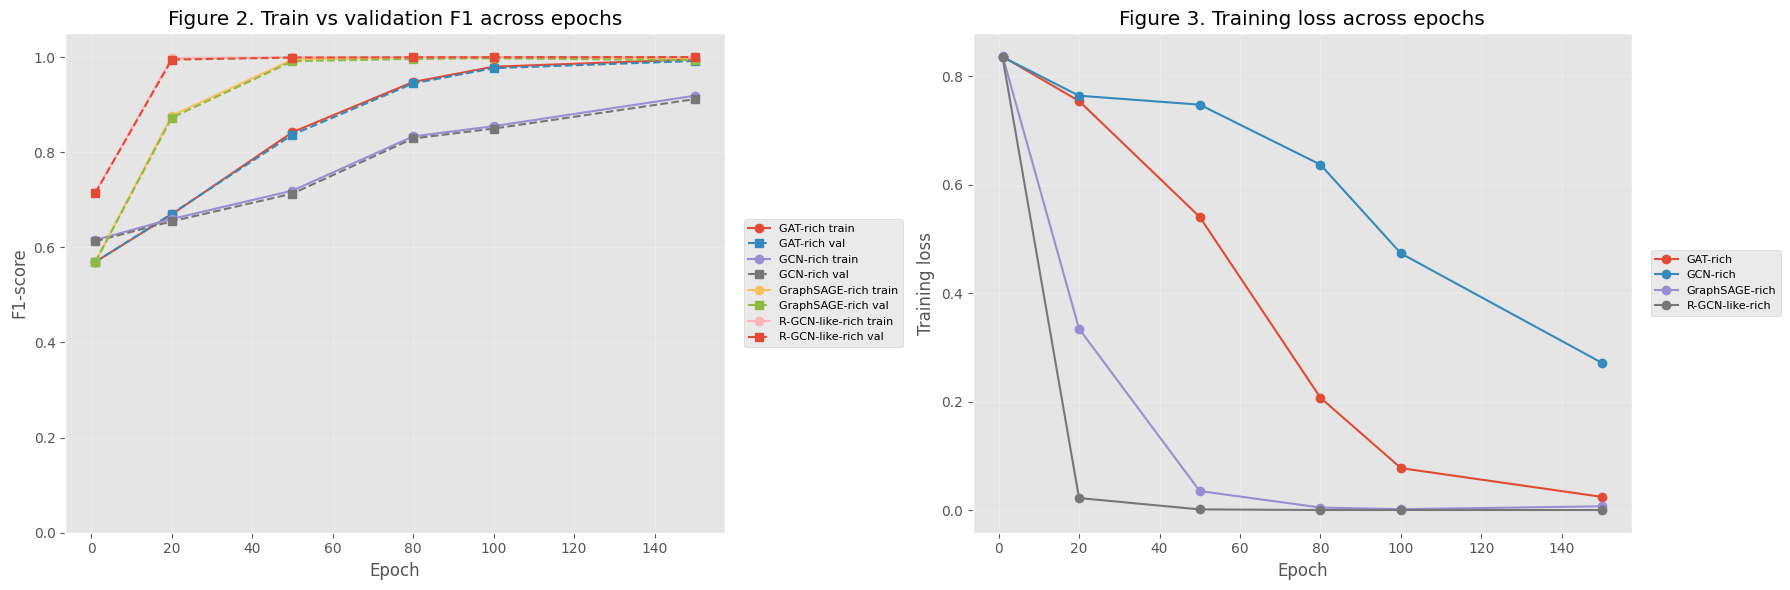

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for model_name, frame in history_df.groupby('model'):
    frame = frame.sort_values('epoch')
    axes[0].plot(frame['epoch'], frame['train_f1'], marker='o', label=f'{model_name} train')
    axes[0].plot(frame['epoch'], frame['val_f1'], marker='s', linestyle='--', label=f'{model_name} val')

axes[0].set_title('Figure 2. Train vs validation F1 across epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
axes[0].grid(alpha=0.25)

for model_name, frame in history_df.groupby('model'):
    frame = frame.sort_values('epoch')
    axes[1].plot(frame['epoch'], frame['train_loss'], marker='o', label=model_name)

axes[1].set_title('Figure 3. Training loss across epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training loss')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [17]:
# Automatically summarize possible overfitting or plateau behavior.
learning_summary_rows = []
for model_name, frame in history_df.groupby('model'):
    frame = frame.sort_values('epoch')
    best_idx = frame['val_f1'].idxmax()
    best_epoch = int(frame.loc[best_idx, 'epoch'])
    first_val = float(frame.iloc[0]['val_f1'])
    best_val = float(frame.loc[best_idx, 'val_f1'])
    last_val = float(frame.iloc[-1]['val_f1'])
    last_train = float(frame.iloc[-1]['train_f1'])
    gap = last_train - last_val
    if best_epoch < int(frame.iloc[-1]['epoch']) and gap > 0.05:
        interpretation = 'possible overfitting after best epoch'
    elif abs(last_val - best_val) < 0.01:
        interpretation = 'validation performance plateaued near final epoch'
    else:
        interpretation = 'still changing across checkpoints'
    learning_summary_rows.append({
        'model': model_name,
        'best_val_epoch': best_epoch,
        'first_val_f1': first_val,
        'best_val_f1': best_val,
        'last_val_f1': last_val,
        'last_train_f1': last_train,
        'train_minus_val_gap_at_last_epoch': gap,
        'interpretation': interpretation
    })

learning_summary_df = pd.DataFrame(learning_summary_rows).sort_values('best_val_f1', ascending=False)
print('Table 7. Learning-curve interpretation by GNN type')
display(learning_summary_df.round(4))

Table 7. Learning-curve interpretation by GNN type


,model,best_val_epoch,first_val_f1,best_val_f1,last_val_f1,last_train_f1,train_minus_val_gap_at_last_epoch,interpretation
3,R-GCN-like-rich,150,0.7142,1.0000,1.0000,1.0000,0.0000,validation performance plateaued near final epoch
2,GraphSAGE-rich,100,0.5693,0.9975,0.9935,0.9978,0.0043,validation performance plateaued near final epoch
0,GAT-rich,150,0.5693,0.9919,0.9919,0.9953,0.0034,validation performance plateaued near final epoch
1,GCN-rich,150,0.6128,0.9117,0.9117,0.9188,0.0071,validation performance plateaued near final epoch


## 16. Compare against previous methods

This table places the rich-graph GNN results next to the earlier reference results from the baseline notebook.

The reference values are included so we can answer the practical question:

> Did richer graph construction help enough to challenge k-NN?

Based on the current Table 8 output, the richer graph GNN variants do not merely improve over the earlier simple KG+GNN; they also outperform the previous k-NN reference on the random held-out test split.

This is an important result for the research question, but it should be interpreted carefully because the very high scores suggest that the richer graph may be capturing extremely strong device, state, IP, port, protocol, and time-window patterns. For the paper, this should be reported as a strong result under the current random window-level split, followed by a recommendation to validate it later with stricter splits such as time-based holdout or device-based holdout.

In [18]:
baseline_comparison_path = BASE_PATH / 'Notebooks' / 'baseline_final_comparison.csv'

if baseline_comparison_path.exists():
    reference_rows = pd.read_csv(baseline_comparison_path)
    print(f'Imported baseline comparison from: {baseline_comparison_path}')
else:
    # Fallback values from the baseline notebook Table 15.
    reference_rows = pd.DataFrame([
        {'model': 'k-NN', 'accuracy': 0.9229, 'precision': 0.9723, 'recall': 0.8299, 'f1': 0.8954, 'roc_auc': 0.9310, 'family': 'Classical baseline'},
        {'model': 'Logistic Regression', 'accuracy': 0.9005, 'precision': 0.9541, 'recall': 0.7878, 'f1': 0.8630, 'roc_auc': 0.9129, 'family': 'Classical baseline'},
        {'model': 'QDA', 'accuracy': 0.8934, 'precision': 0.9709, 'recall': 0.7547, 'f1': 0.8492, 'roc_auc': 0.9037, 'family': 'Classical baseline'},
        {'model': 'LDA', 'accuracy': 0.8915, 'precision': 0.9834, 'recall': 0.7399, 'f1': 0.8445, 'roc_auc': 0.9018, 'family': 'Classical baseline'},
        {'model': 'Graph 2 - Dual-class affinity graph', 'accuracy': 0.8845, 'precision': 0.9210, 'recall': 0.7762, 'f1': 0.8424, 'roc_auc': 0.9018, 'family': 'Graph analysis'},
        {'model': 'Naive Bayes', 'accuracy': 0.8841, 'precision': 0.9449, 'recall': 0.7525, 'f1': 0.8378, 'roc_auc': 0.8826, 'family': 'Classical baseline'},
        {'model': 'Graph 3 - State co-occurrence graph', 'accuracy': 0.8800, 'precision': 0.9243, 'recall': 0.7606, 'f1': 0.8345, 'roc_auc': 0.8857, 'family': 'Graph analysis'},
        {'model': 'Knowledge graph + Simple GNN', 'accuracy': 0.8495, 'precision': 0.9054, 'recall': 0.6943, 'f1': 0.7859, 'roc_auc': 0.8799, 'family': 'GNN'},
        {'model': 'Graph 1 - Benign novelty graph', 'accuracy': 0.8214, 'precision': 0.9995, 'recall': 0.5514, 'f1': 0.7107, 'roc_auc': 0.7756, 'family': 'Graph analysis'},
    ])

rich_gnn_compare = gnn_results_df.copy()
rich_gnn_compare['family'] = 'Rich graph GNN'
rich_gnn_compare = rich_gnn_compare[['family', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

final_comparison_df = pd.concat([reference_rows, rich_gnn_compare], ignore_index=True)
final_comparison_df = final_comparison_df.drop_duplicates(subset=['model'], keep='last')
final_comparison_df = final_comparison_df.sort_values('f1', ascending=False, na_position='last').reset_index(drop=True)

print('Table 8. Final comparison: baseline references vs rich-graph GNN variants')
display(final_comparison_df.round(4))

Imported baseline comparison from: /Users/hectorcas13/Library/CloudStorage/Dropbox/Universidad/PhD-Albany/CINF897-Independent_Study&Resarch/Notebooks/baseline_final_comparison.csv
Table 8. Final comparison: baseline references vs rich-graph GNN variants


,model,accuracy,precision,recall,f1,roc_auc,family
0,R-GCN-like-rich,1.0000,0.9999,1.0000,1.0000,1.0000,Rich graph GNN
1,GraphSAGE-rich,0.9982,0.9989,0.9966,0.9978,0.9998,Rich graph GNN
2,GAT-rich,0.9935,0.9909,0.9926,0.9918,0.9968,Rich graph GNN
3,GCN-rich,0.9298,0.9095,0.9147,0.9121,0.9707,Rich graph GNN
4,k-NN,0.9229,0.9723,0.8299,0.8954,0.9310,Classical baseline
5,Logistic Regression,0.9005,0.9541,0.7878,0.8630,0.9129,Classical baseline
6,QDA,0.8934,0.9709,0.7547,0.8492,0.9037,Classical baseline
7,LDA,0.8915,0.9834,0.7399,0.8445,0.9018,Classical baseline
8,Graph 2 - Dual-class affinity graph,0.8845,0.9210,0.7762,0.8424,0.9018,Graph analysis
9,Naive Bayes,0.8841,0.9449,0.7525,0.8378,0.8826,Classical baseline


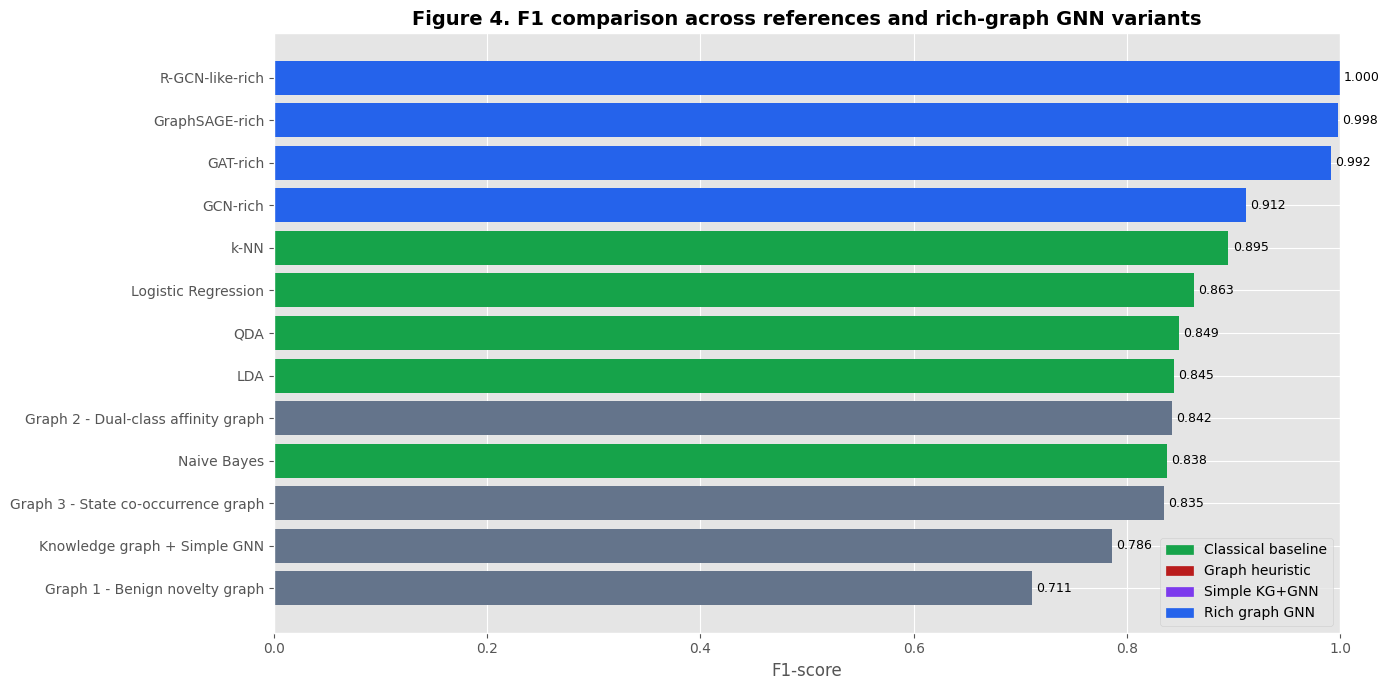

In [19]:
plot_df = final_comparison_df[final_comparison_df['f1'].notna()].sort_values('f1')
color_map = {
    'Classical baseline': '#16a34a',
    'Graph heuristic': '#b91c1c',
    'Simple KG+GNN': '#7c3aed',
    'Rich graph GNN': '#2563eb'
}
fig, ax = plt.subplots(figsize=(14, 7))
colors = plot_df['family'].map(color_map).fillna('#64748b')
bars = ax.barh(plot_df['model'], plot_df['f1'], color=colors)
ax.set_title('Figure 4. F1 comparison across references and rich-graph GNN variants', fontsize=14, fontweight='bold')
ax.set_xlabel('F1-score')
ax.set_xlim(0, 1.0)
ax.bar_label(bars, labels=[f'{v:.3f}' for v in plot_df['f1']], padding=3, fontsize=9)
handles = [plt.Rectangle((0,0),1,1,color=color,label=family) for family, color in color_map.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

## 17. Final heatmap

The heatmap shows the full metric profile across all rich-graph GNN variants and the imported baseline comparison table.

How to read it:

- each row is a model,
- each column is a metric,
- redder cells mean higher values,
- bluer cells mean lower values,
- white lines separate the cells,
- each cell shows the metric value and the same value as a percentage,
- missing values appear gray only if a model was not executed or a metric was not available.

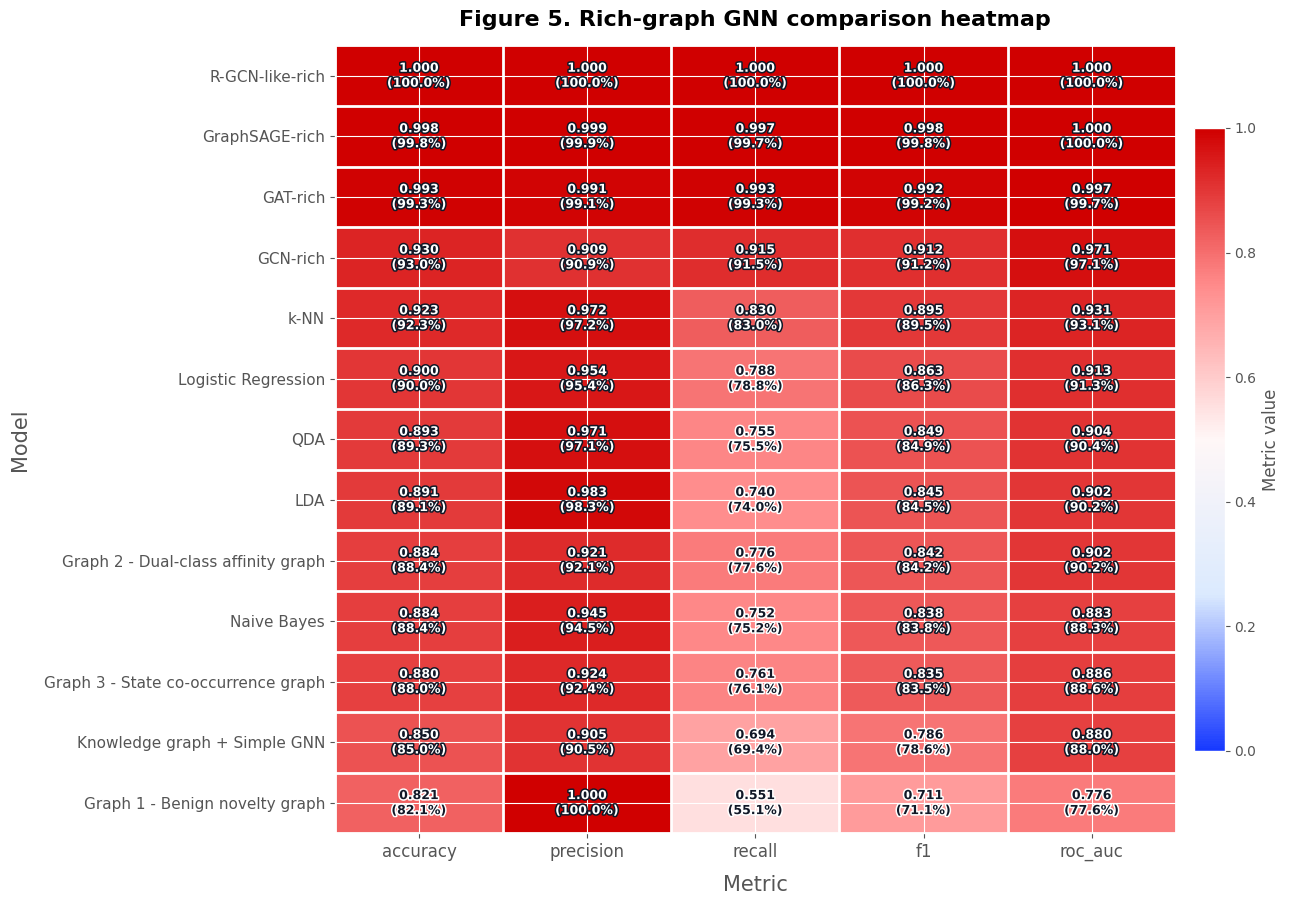

In [20]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
heatmap_df = final_comparison_df.set_index('model')[metrics_cols].copy()
values = heatmap_df.values.astype(float)
masked = np.ma.masked_invalid(values)

metric_cmap = LinearSegmentedColormap.from_list(
    'metric_blue_white_red',
    ['#1739ff', '#dbeafe', '#fff7f7', '#ff8a8a', '#d00000'],
    N=256
)
metric_cmap.set_bad(color='#e5e7eb')

fig_h = max(6, 0.55 * len(heatmap_df) + 2)
fig, ax = plt.subplots(figsize=(13, fig_h))
im = ax.imshow(masked, cmap=metric_cmap, vmin=0, vmax=1, aspect='auto')
ax.set_title('Figure 5. Rich-graph GNN comparison heatmap', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Metric', fontsize=15, labelpad=10)
ax.set_ylabel('Model', fontsize=15, labelpad=10)
ax.set_xticks(np.arange(len(metrics_cols)))
ax.set_xticklabels(metrics_cols, rotation=0, fontsize=12)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=11)

# White grid lines between cells, matching the reference heatmap style.
ax.set_xticks(np.arange(-0.5, len(metrics_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_df.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2.0)
ax.tick_params(which='minor', bottom=False, left=False)

norm = plt.Normalize(vmin=0, vmax=1)
for i in range(masked.shape[0]):
    for j in range(masked.shape[1]):
        if np.ma.is_masked(masked[i, j]):
            text = 'NA'
            color = '#111827'
            stroke = 'white'
        else:
            v = float(masked[i, j])
            text = f'{v:.3f}\n({v*100:.1f}%)'
            r, g, b, _ = metric_cmap(norm(v))
            luminance = 0.299*r + 0.587*g + 0.114*b
            color = 'white' if luminance < 0.55 else '#111827'
            stroke = '#111827' if color == 'white' else 'white'
        t = ax.text(j, i, text, ha='center', va='center', color=color, fontsize=9, fontweight='bold')
        t.set_path_effects([pe.withStroke(linewidth=2.2, foreground=stroke)])

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Metric value')
plt.tight_layout()
plt.show()

## 18. Final interpretation

The current results show that the richer graph representation substantially improves GNN performance. In Table 8, the rich-graph GNN variants outperform the original simple KG+GNN and also outperform the previous k-NN reference on the random held-out test split. This changes the main interpretation: the earlier simple graph was not rich enough, but adding device, behavior-state, IP, port, protocol, and temporal nodes gave the GNN much more useful relational information.

The strongest result is the `R-GCN-like-rich` model, which reaches near-perfect or perfect performance in the current run. That is promising, but it should not be reported blindly as final proof that GNNs always beat tabular models. A score that high can happen when the graph representation captures very strong repeated patterns across random train/test windows. For the paper, the safest conclusion is that **rich graph construction outperforms the classical baseline under the current random window-level split**, and the next research step should test stricter validation designs such as time-based holdout, device-based holdout, or attack-family holdout.

Learning-curve interpretation: if validation F1 stops improving before 150 epochs while training F1 keeps increasing, that suggests overfitting or memorization. If both training and validation F1 flatten together, the model likely reached its learning limit with the current graph design.